In [174]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


(4199, 3000, 3)


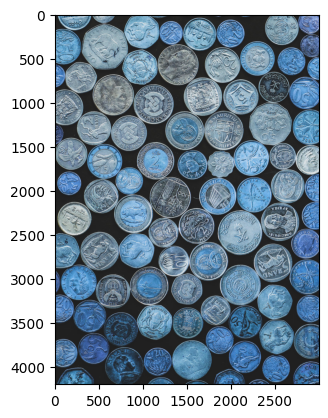

In [175]:
img = cv2.imread("koins.jpg")
gray= cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print(img.shape)
plt.imshow(img)

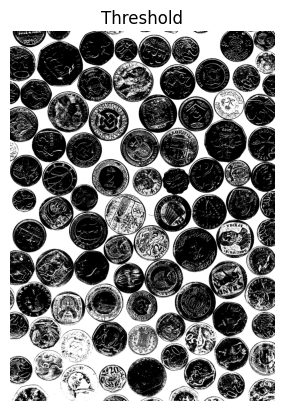

In [176]:
_, binary = cv2.threshold(gray,0,255,cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
plt.imshow(binary, cmap='gray')
plt.title("Threshold")
plt.axis("off")
plt.show()

In [177]:
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=2)

In [178]:
sure_bg = cv2.dilate(opening, kernel, iterations=3)

In [179]:
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2,5)

In [180]:
_, sure_fg = cv2.threshold(dist_transform, 0.5*dist_transform.max(),355, 0)

In [181]:
sure_fg = np.uint8(sure_fg)

In [182]:
unknown = cv2.subtract(sure_bg , sure_fg)

In [183]:
num_labels, markers = cv2.connectedComponents(sure_fg)

In [184]:
markers = markers +1
markers[unknown == 255] = 0
markers = cv2.watershed(img, markers)

In [185]:
r = img.copy()
r[markers == -1] = [0,0,255]

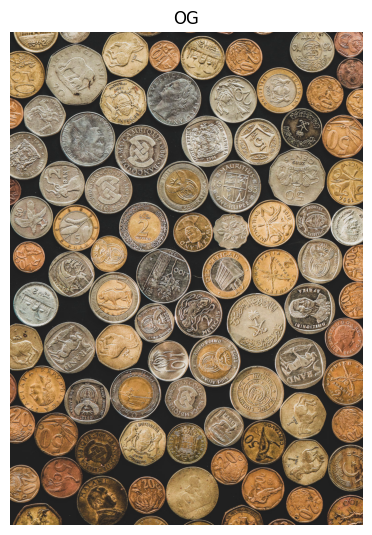

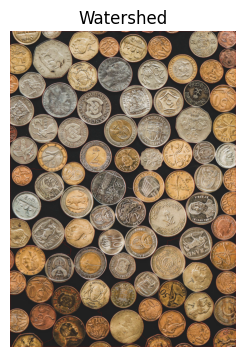

In [186]:
plt.figure(figsize=(10,15))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("OG")
plt.axis("off")
plt.show()

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(r,cv2.COLOR_BGR2RGB ))
plt.title("Watershed")
plt.axis("off")
plt.show()